In [1]:
# Environment Setup
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report

def build_and_train_model():
    print("Starting Phase 1: Building the Brain...")

    # Generate Synthetic Data
    np.random.seed(42) # Ensures we get the same "random" data every time
    n_samples = 1000

    # Generating realistic medical ranges
    data = {
        'glucose_7d_avg': np.random.normal(loc=9.0, scale=3.5, size=n_samples).round(1), # mmol/L
        'systolic_bp': np.random.normal(loc=130, scale=15, size=n_samples).astype(int),
        'diastolic_bp': np.random.normal(loc=80, scale=10, size=n_samples).astype(int),
        'days_since_appt': np.random.randint(1, 180, size=n_samples),
        'symptom_severity_score': np.random.randint(1, 11, size=n_samples) # 1 to 10
    }

    df = pd.DataFrame(data)

    # Hardcoding the medical triage logic for the target variable (Risk Tier)
    # 2 = Critical, 1 = Urgent Appointment, 0 = Routine
    def assign_risk_tier(row):
        # Critical Alert: High glucose + high symptoms, OR dangerously high BP
        if (row['glucose_7d_avg'] >= 14.0 and row['symptom_severity_score'] >= 7) or row['systolic_bp'] >= 165:
            return 2
        # Urgent: Elevated glucose or moderate symptoms
        elif (row['glucose_7d_avg'] >= 10.0 and row['glucose_7d_avg'] < 14.0) or row['symptom_severity_score'] >= 5:
            return 1
        # Routine: Stable metrics
        else:
            return 0

    df['risk_tier'] = df.apply(assign_risk_tier, axis=1)

    print(f"Dataset generated with {n_samples} patient records.")
    print("Class distribution:")
    print(df['risk_tier'].value_counts())
    print("-" * 30)

    # Save the generated data to a CSV for the software engineers
    df.to_csv('synthetic_diabetes_patients.csv', index=False)

    # Train the Model
    # Separate features (X) and target (y)
    X = df.drop('risk_tier', axis=1)
    y = df['risk_tier']

    # Split into 80% training and 20% testing
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and train the Random Forest
    print("Training Random Forest Classifier")
    model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)

    # Extract Performance Metrics
    y_pred = model.predict(X_test)

    # Calculate metrics (using 'weighted' to account for class imbalances)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')

    print("\n--- PERFORMANCE METRICS (FOR PITCH DECK) ---")
    print(f"Accuracy:  {accuracy * 100:.1f}%")
    print(f"Precision: {precision * 100:.1f}%")
    print(f"Recall:    {recall * 100:.1f}%")
    print("\nDetailed Report:")
    print(classification_report(y_test, y_pred))

    return model, X, X_test

# Execute the pipeline
trained_model, X_full, X_test_data = build_and_train_model()

Starting Phase 1: Building the Brain...
Dataset generated with 1000 patient records.
Class distribution:
risk_tier
1    680
0    268
2     52
Name: count, dtype: int64
------------------------------
Training Random Forest Classifier

--- PERFORMANCE METRICS (FOR PITCH DECK) ---
Accuracy:  99.0%
Precision: 99.0%
Recall:    99.0%

Detailed Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        45
           1       0.99      1.00      0.99       146
           2       1.00      0.78      0.88         9

    accuracy                           0.99       200
   macro avg       1.00      0.93      0.96       200
weighted avg       0.99      0.99      0.99       200



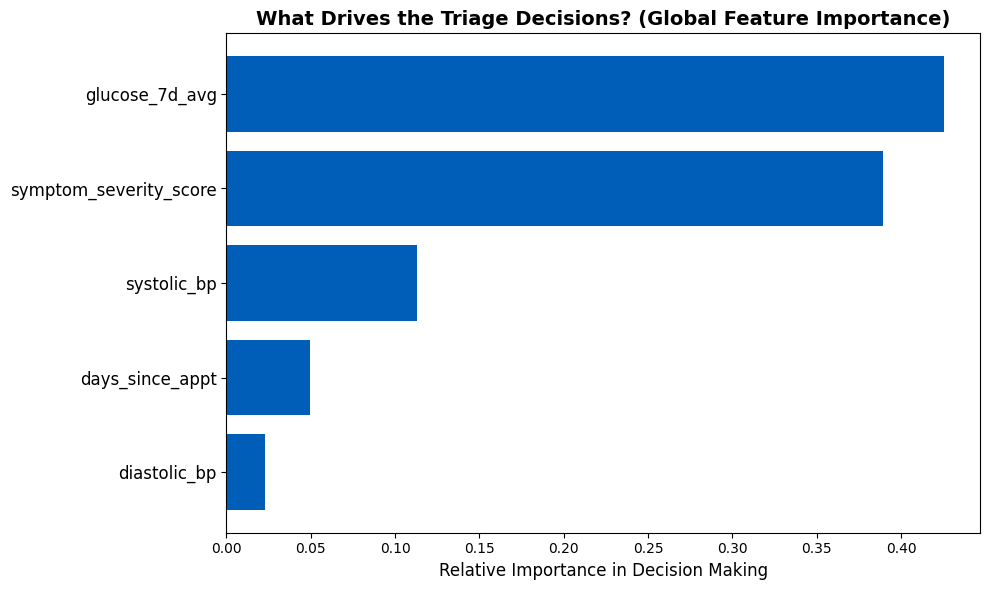

In [2]:
# GLOBAL FEATURE IMPORTANCE
import matplotlib.pyplot as plt
import numpy as np

# 1. Extract feature importances and names
importances = trained_model.feature_importances_
feature_names = X_full.columns

# 2. Sort them in descending order
indices = np.argsort(importances)

# 3. Create the plot
plt.figure(figsize=(10, 6))
plt.title("What Drives the Triage Decisions? (Global Feature Importance)", fontsize=14, fontweight='bold')
plt.barh(range(len(indices)), importances[indices], color='#005EB8', align='center') # NHS Blue
plt.yticks(range(len(indices)), [feature_names[i] for i in indices], fontsize=12)
plt.xlabel("Relative Importance in Decision Making", fontsize=12)

# 4. Save and show
plt.tight_layout()
plt.savefig('global_feature_importance.png', dpi=300)
plt.show()



Calculating SHAP values... this might take a few seconds.


/tmp/ipykernel_158/2629812959.py:19: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[:, :, 2], X_subset, show=False)


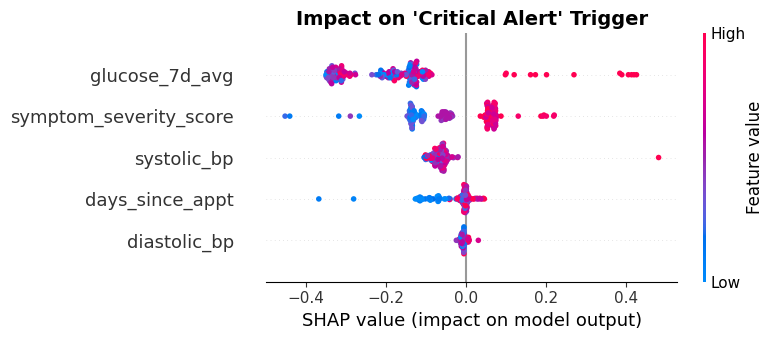

In [3]:
# SHAP SUMMARY PLOT
import shap
import matplotlib.pyplot as plt

# 1. Initialize the SHAP explainer
print("Calculating SHAP values... this might take a few seconds.")
explainer = shap.TreeExplainer(trained_model)

# 2. Calculate SHAP values for the dataset
# We use a subset (e.g., 200 rows) to make it run faster for the hackathon
X_subset = X_full.sample(200, random_state=42)
shap_values = explainer(X_subset)

# 3. Generate the summary plot specifically for Class 2 (Critical Alerts)
plt.figure(figsize=(10, 6))
plt.title("Impact on 'Critical Alert' Trigger", fontsize=14, fontweight='bold')

# shap_values[:, :, 2] isolates the explanations for the "Critical" class
shap.summary_plot(shap_values[:, :, 2], X_subset, show=False)

# 4. Save and show
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
plt.show()


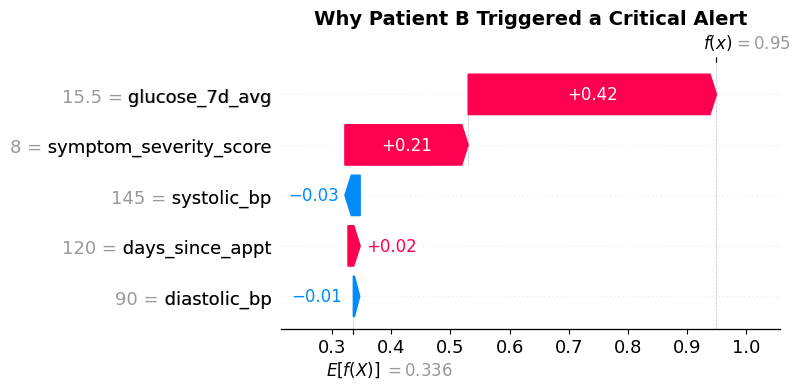

In [4]:
# SHAP WATERFALL PLOT FOR DEMO PATIENT
import shap
import pandas as pd
import matplotlib.pyplot as plt

# 1. Create the exact data for Demo Patient B (Critical Case)
patient_b_data = {
    'glucose_7d_avg': [15.5],
    'systolic_bp': [145],
    'diastolic_bp': [90],
    'days_since_appt': [120],
    'symptom_severity_score': [8]
}
patient_b_df = pd.DataFrame(patient_b_data)

# 2. Run the single patient through the explainer
shap_values_patient = explainer(patient_b_df)

# 3. Plot the waterfall chart for Class 2 (Critical)
plt.figure(figsize=(10, 6))

# shap_values_patient[0, :, 2] selects the first patient, all features, Class 2
shap.plots.waterfall(shap_values_patient[0, :, 2], show=False)

# 4. Save and show
plt.title("Why Patient B Triggered a Critical Alert", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_patient_waterfall.png', dpi=300, bbox_inches='tight')
plt.show()
